# Posterior for local recombination rate using SBI (real genes)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
from torch.distributions import Uniform
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from newick_to_tree import newick_to_tree
from discrete_uniform import DiscreteUniform

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load staph gene data and clonal tree.

In [2]:
np.random.seed(100)
clonal_tree = ClonalTree(n=110)

# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/staph/saureus_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

                                                                   , C1139
                                                                  ,|
                                                                  |, C9658
                                                                  ||
                                                                  |, C1282
                                                                  ||
                      ____________________________________________|, C1280
                     |                                            ||
                     |                                            || C1080
                     |                                            |
                     |                                            |_ C1079
                     |                                            |
                     |                                            , C1147
                     |                                          

In [3]:
x_obs_df = pd.read_csv("../data/staph/core_gene_summary_stats.csv", index_col=0)
x_obs_np = x_obs_df.to_numpy()
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([1983, 46]), torch.float32)

## Load simulation data

In [4]:
theta1 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/staph/ClonalOrigin_sim/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/staph/ClonalOrigin_sim/x2.csv', delimiter=",")

theta3 = np.loadtxt('../data/staph/ClonalOrigin_sim/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/staph/ClonalOrigin_sim/x3.csv', delimiter=",")

x = np.vstack([x1, x2, x3])
theta = np.vstack([theta1, theta2, theta3])

print(theta.shape, x.shape)

(50000, 2) (50000, 46)


In [5]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

## NPE

### Create prior to pass range knowledge to NPE

In [6]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([20.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_L],
    validate_args=False,
    device=torch_device
)

In [7]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [8]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\npe\npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 4, 5, 8, 9, 12, 13, 18, 19, 20, 21, 24, 25, 26, 28, 29, 32, 33, 36, 38, 39, 41, 42, 43, 44] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 148 epochs.

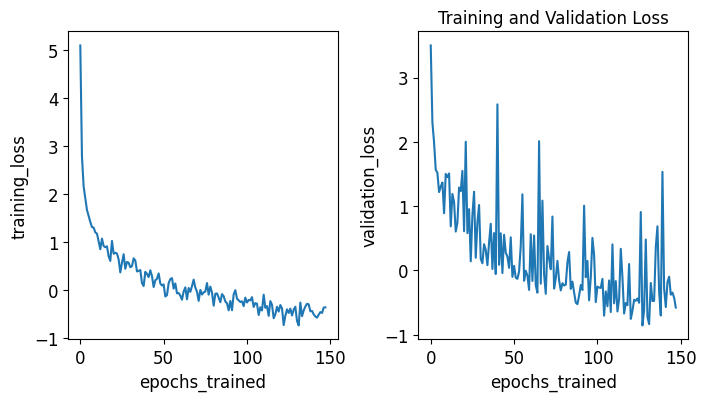

In [9]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Plug in observation data to get posterior

In [10]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 2), np.nan)
theta_post.shape

(1983, 1000, 2)

In [11]:
ignore_indices = []
for i in range(x_obs_torch.shape[0]):
    ignore_i = False
    for j in range(46):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
    if ignore_i or torch.isnan(x_obs_torch[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data. Skipping.")
        ignore_indices.append(i)

Observation 5 is outside the range of simulated data. Skipping.
Observation 6 is outside the range of simulated data. Skipping.
Observation 7 is outside the range of simulated data. Skipping.
Observation 8 is outside the range of simulated data. Skipping.
Observation 20 is outside the range of simulated data. Skipping.
Observation 22 is outside the range of simulated data. Skipping.
Observation 27 is outside the range of simulated data. Skipping.
Observation 29 is outside the range of simulated data. Skipping.
Observation 30 is outside the range of simulated data. Skipping.
Observation 31 is outside the range of simulated data. Skipping.
Observation 35 is outside the range of simulated data. Skipping.
Observation 39 is outside the range of simulated data. Skipping.
Observation 47 is outside the range of simulated data. Skipping.
Observation 64 is outside the range of simulated data. Skipping.
Observation 82 is outside the range of simulated data. Skipping.
Observation 85 is outside the

In [13]:
skip_indices = []
for i in range(x_obs_torch.shape[0]):
    if i in ignore_indices:
        skip_indices.append(i)
        continue
    try:
        theta_post_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                            show_progress_bars=False, max_sampling_time=5.0)
        theta_post[i, :, :] = theta_post_torch.cpu().numpy()
    except RuntimeError as e:
        print(f"Skipping observation {i} due to sampling timeout: {e}")
        skip_indices.append(i)
        continue

                    accepted. It may take a long time to collect the remaining
                    1000 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


Skipping observation 191 due to sampling timeout: Sampling aborted early because rejection sampling exceeded max_sampling_time. This is likely due to extremely low acceptance. You can disable rejection sampling using `reject_outside_prior=False` to draw samples directly from the trained estimator. Consider switching to MCMC or VI, or checking for model misspecification.


                    accepted. It may take a long time to collect the remaining
                    984 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.
                    accepted. It may take a long time to collect the remaining
                    985 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.
            

Skipping observation 239 due to sampling timeout: Sampling aborted early because rejection sampling exceeded max_sampling_time. This is likely due to extremely low acceptance. You can disable rejection sampling using `reject_outside_prior=False` to draw samples directly from the trained estimator. Consider switching to MCMC or VI, or checking for model misspecification.


                    accepted. It may take a long time to collect the remaining
                    1000 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


...

                    accepted. It may take a long time to collect the remaining
                    1000 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


Skipping observation 1782 due to sampling timeout: Sampling aborted early because rejection sampling exceeded max_sampling_time. This is likely due to extremely low acceptance. You can disable rejection sampling using `reject_outside_prior=False` to draw samples directly from the trained estimator. Consider switching to MCMC or VI, or checking for model misspecification.


                    accepted. It may take a long time to collect the remaining
                    983 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.
                    accepted. It may take a long time to collect the remaining
                    989 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.
            

Skipping observation 1835 due to sampling timeout: Sampling aborted early because rejection sampling exceeded max_sampling_time. This is likely due to extremely low acceptance. You can disable rejection sampling using `reject_outside_prior=False` to draw samples directly from the trained estimator. Consider switching to MCMC or VI, or checking for model misspecification.


                    accepted. It may take a long time to collect the remaining
                    924 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


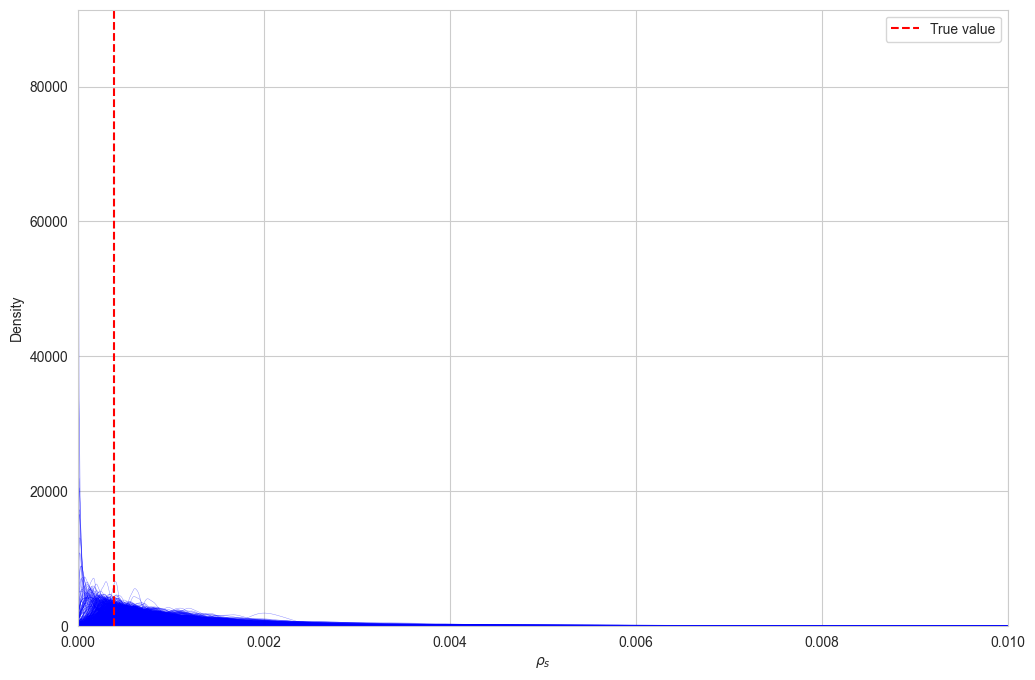

In [15]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    if i in skip_indices:
        continue
    sns.kdeplot(theta_post[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
plt.axvline(x=0.0003887292720131564, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.01)
plt.legend()
plt.show()

In [16]:
theta_post2 = np.full((x_obs_torch.shape[0], num_posterior_samples, 2), np.nan)
theta_post2.shape

(1983, 1000, 2)

In [24]:
for i in range(x_obs_torch.shape[0]):
    if i in ignore_indices:
        continue

    theta_post2_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                        show_progress_bars=False, reject_outside_prior=False)
    theta_post2[i, :, :] = theta_post2_torch.cpu().detach().numpy()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_23764\3024975635.py:5: UserWarning: 23.6% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  theta_post2_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
C:\Users\u2008181\AppData\Local\Temp\ipykernel_23764\3024975635.py:5: UserWarning: 80.4% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  theta_post2_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
C:\Users\u2008181\AppData\Local\Temp\ipykernel_23764\3024975635.py:5: UserWarning: 5.5% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  theta_post2_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
C:\Users\u2008181\AppData\Local\Temp\ipykernel_23764\3024975635.py:5: UserWarning: 100.0% of samples drawn with reject_out

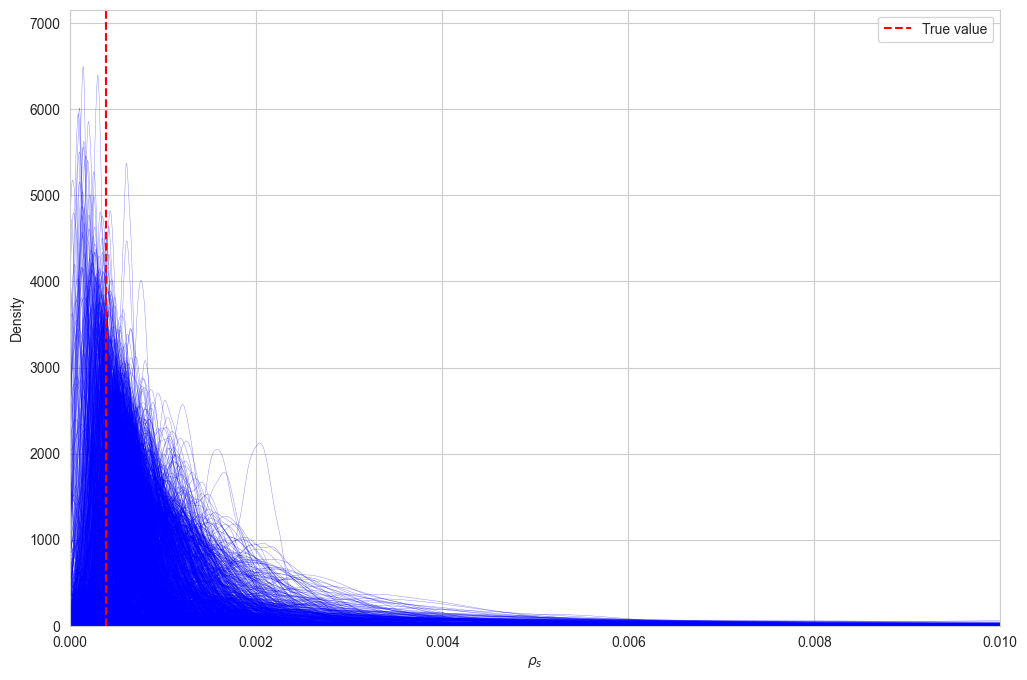

In [25]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    if i in ignore_indices:
        continue
    sns.kdeplot(theta_post2[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
plt.axvline(x=0.0003887292720131564, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.01)
plt.legend()
plt.show()

### Plot bar plots by position

In [29]:
gene_info = pd.read_csv("../data/staph/core_gene_summary.csv", index_col=0)
gene_info_np = gene_info.to_numpy()
gene_info.head()

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
dnaA,1362,517,1878,True
dnaN,1134,2156,3289,True
SAR0003,246,3670,3915,True
recF,1113,3912,5024,True
gyrB,1932,5037,6968,True


In [66]:
plot_xlim = [0.0, 2902619.0]
samples_x1 = np.delete(gene_info_np[:, 1], skip_indices)
samples_x2 = np.delete(gene_info_np[:, 1], ignore_indices)

theta_post_nonan = np.delete(theta_post[:, :, 0], skip_indices, axis=0)
theta_post2_nonan = np.delete(theta_post2[:, :, 0], ignore_indices, axis=0)

In [67]:
theta_post_nonan.shape, theta_post2_nonan.shape, samples_x1.shape, samples_x2.shape

((1658, 1000), (1683, 1000), (1658,), (1683,))

In [68]:
posterior1_median = np.median(theta_post_nonan, axis=1)
posterior2_median = np.median(theta_post2_nonan, axis=1)
posterior1_median.shape, posterior2_median.shape

((1658,), (1683,))

In [69]:
ci_lower_bounds1 = np.percentile(theta_post_nonan, 2.5, axis=1)
ci_upper_bounds1 = np.percentile(theta_post_nonan, 97.5, axis=1)
ci_lower_bounds2 = np.percentile(theta_post2_nonan, 2.5, axis=1)
ci_upper_bounds2 = np.percentile(theta_post2_nonan, 97.5, axis=1)
ci_lower_bounds1.shape, ci_upper_bounds1.shape, ci_lower_bounds2.shape, ci_upper_bounds2.shape

((1658,), (1658,), (1683,), (1683,))

In [70]:
lower1_errors = posterior1_median - ci_lower_bounds1
upper1_errors = ci_upper_bounds1 - posterior1_median
lower2_errors = posterior2_median - ci_lower_bounds2
upper2_errors = ci_upper_bounds2 - posterior2_median
yerr1 = [lower1_errors, upper1_errors]
yerr2 = [lower2_errors, upper2_errors]

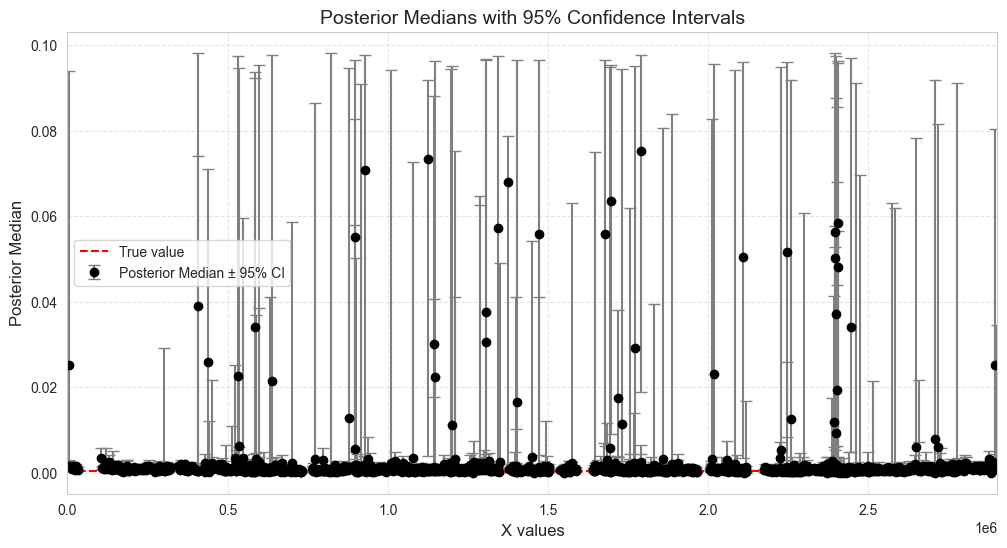

In [72]:
plt.figure(figsize=(12, 6))
plt.errorbar(samples_x1, posterior1_median, yerr=yerr1, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals", fontsize=14)
plt.xlabel("X values", fontsize=12)
plt.ylabel("Posterior Median", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.0003887292720131564, color='red', linestyle='dashed', label='True value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

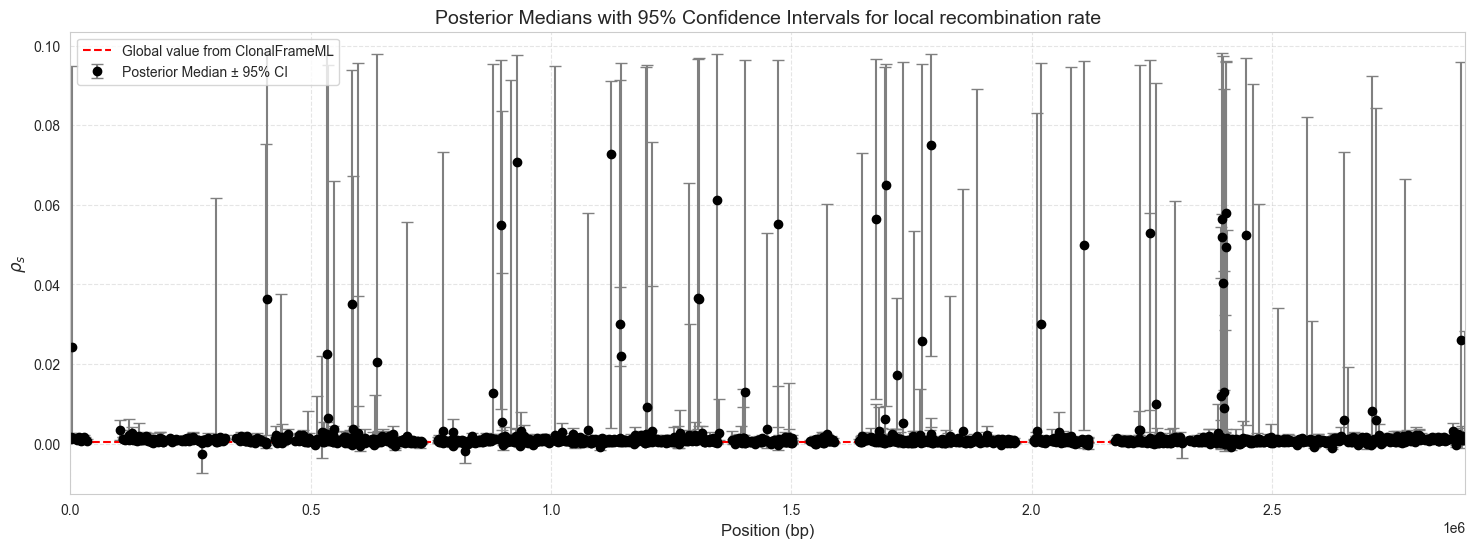

In [78]:
plt.figure(figsize=(18, 6))
plt.errorbar(samples_x2, posterior2_median, yerr=yerr2, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for local recombination rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\rho_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.0003887292720131564, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.xlim(plot_xlim)
plt.legend(loc='upper left')
plt.show()

In [79]:
len(ignore_indices)

300

In [80]:
samples_l2 = np.delete(gene_info_np[:, 0], ignore_indices)
theta_post_l2_nonan = np.delete(theta_post2[:, :, 1], ignore_indices, axis=0)
samples_l2.shape, theta_post_l2_nonan.shape

((1683,), (1683, 1000))

In [81]:
posterior_l2_median = np.median(theta_post_l2_nonan, axis=1)
posterior_l2_median.shape

(1683,)

In [82]:
ci_lower_bounds_l2 = np.percentile(theta_post_l2_nonan, 2.5, axis=1)
ci_upper_bounds_l2 = np.percentile(theta_post_l2_nonan, 97.5, axis=1)
ci_lower_bounds_l2.shape, ci_upper_bounds_l2.shape

((1683,), (1683,))

In [83]:
lower_l2_errors = posterior_l2_median - ci_lower_bounds_l2
upper_l2_errors = ci_upper_bounds_l2 - posterior_l2_median
yerr_l2 = [lower_l2_errors, upper_l2_errors]

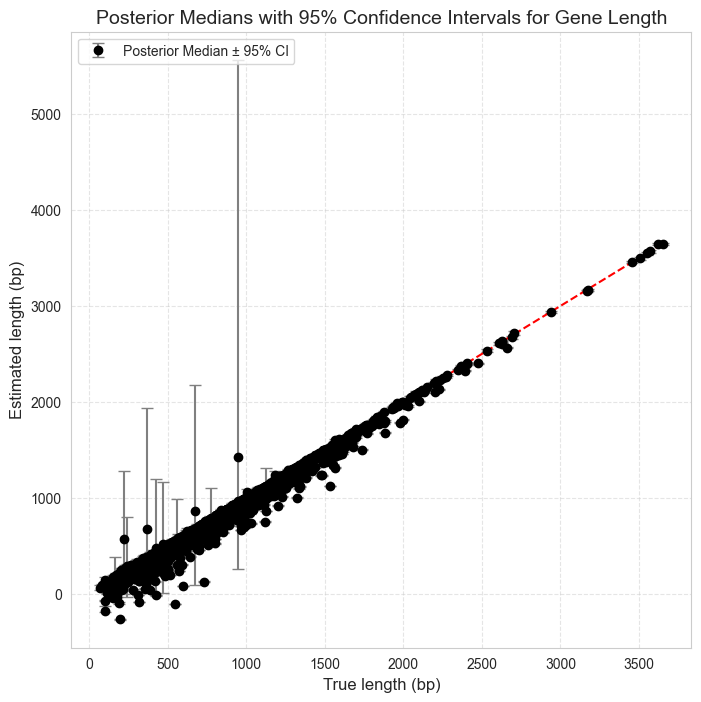

In [85]:
plt.figure(figsize=(8, 8))
plt.errorbar(samples_l2, posterior_l2_median, yerr=yerr_l2, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

exact_x = np.linspace(np.min(samples_l2), np.max(samples_l2), 400)
exact_y = exact_x

plt.title("Posterior Medians with 95% Confidence Intervals for Gene Length", fontsize=14)
plt.xlabel("True length (bp)", fontsize=12)
plt.ylabel("Estimated length (bp)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()